In [ ]:
#| export
import os, subprocess, json, re, sys
from pathlib import Path
from IPython.display import HTML, display

In [ ]:
#| export
def export_ipynb_to_tex(ipynb_path: str, output_path: str = None):
    "Export a Solveit dialog (.ipynb) to a compilable LaTeX file."
    
    ipynb_path = os.path.expanduser(ipynb_path)
    output_path = os.path.expanduser(output_path) if output_path else Path(ipynb_path).with_suffix('.tex')

    nb = json.loads(Path(ipynb_path).read_text())
    preamble_lines = []
    body_lines = []
    past_abstract = False

    for cell in nb['cells']:
        content = ''.join(cell['source'])

        if cell['cell_type'] != 'raw' and '#| export' not in content:
            continue

        if cell['cell_type'] == 'raw' and '#| export' not in content:
            continue

        filtered = '\n'.join(l for l in content.split('\n') if not l.startswith('#| '))

        if cell['cell_type'] == 'raw' and not past_abstract:
            preamble_lines.append(filtered)
            continue

        lines = filtered.split('\n')
        i = 0
        while i < len(lines):
            line = lines[i]

            if line.startswith('# ') and not line.startswith('## '):
                preamble_lines.append(f'\\title{{{line[2:].strip()}}}\n')
            elif line.startswith('\\author{'):
                preamble_lines.append(line)
                while i < len(lines) and not lines[i].strip().endswith('}'):
                    i += 1
                    if i < len(lines):
                        preamble_lines.append(lines[i])
                preamble_lines.append('\\begin{document}\n\\maketitle\n')
            elif line == '## Abstract':
                preamble_lines.append('\\begin{abstract}\n')
                i += 1
                while i < len(lines) and not lines[i].startswith('## '):
                    preamble_lines.append(lines[i])
                    i += 1
                preamble_lines.append('\\end{abstract}\n')
                past_abstract = True
                continue
            elif line == '## References':
                body_lines.append('\\small\n')
                bib_match = re.search(r'(\w+)\.bib', content)
                if bib_match:
                    body_lines.append(f'\\bibliographystyle{{unsrt}}\n\\bibliography{{{bib_match.group(1)}}}\n')
                i += 1
                continue
            elif line.startswith('### '):
                body_lines.append(f'\\subsection{{{line[4:].strip()}}}\n')
            elif line.startswith('## '):
                body_lines.append(f'\\section{{{line[3:].strip()}}}\n')
            else:
                body_lines.append(line)

            i += 1

    final = '\\documentclass{article}\n\n'
    final += '\n'.join(preamble_lines) + '\n\n'
    final += '\n'.join(body_lines) + '\n\n'
    final += '\\end{document}\n'
    Path(output_path).write_text(final)
    print(f'Created {output_path}')

In [ ]:
export_ipynb_to_tex('example/neurips_2026.ipynb')

Created example/neurips_2026.tex


In [ ]:
#| export
def get_private_url(path: str):
    "Get the private URL for a file on the solveit cloud instance"
    server = os.getenv('PRIVATE_DOMAIN')
    if not server: raise ValueError("PRIVATE_DOMAIN not set")
    path = os.path.abspath(path)
    return f"https://{server}.solve.it.com{path.replace('/app/data', '/static')}"

In [ ]:
url = get_private_url('example/neurips_2026.tex')
display(HTML(f'<a href="{url}" target="_blank">{url}</a>'))

HTML(<a href="https://serene-vision-dives-ildq3w.solve.it.com/static/solveit-tex/example/neurips_2026.tex" target="_blank">https://serene-vision-dives-ildq3w.solve.it.com/static/solveit-tex/example/neurips_2026.tex</a>)

In [ ]:
#| export
def compile_latex(tex_file: str, cwd: str = '.'):
    "Run full LaTeX compilation: pdflatex → bibtex → pdflatex → pdflatex"

    cwd = os.path.expanduser(cwd)
    tex_file = os.path.expanduser(tex_file)
    
    # Make path absolute before splitting
    full_tex_path = os.path.abspath(os.path.join(cwd, tex_file))
    work_dir = os.path.dirname(full_tex_path)
    
    base_name = os.path.splitext(os.path.basename(full_tex_path))[0]
    tex_content = Path(full_tex_path).read_text()
    bib_match = re.search(r'\\bibliography\{([^}]+)\}', tex_content)
    
    print("Running pdflatex (pass 1)...")
    r1 = subprocess.run(f'pdflatex -halt-on-error {full_tex_path}',
                   shell=True, cwd=work_dir, capture_output=True, text=True)
    if r1.returncode != 0:
        print(f"  FAILED:\n{r1.stdout[-3000:]}")
        return
    
    if bib_match:
        bib_name = bib_match.group(1)
        print(f"\nRunning bibtex ({bib_name})...")
        r = subprocess.run(f'bibtex {base_name}',
                          shell=True, cwd=work_dir, capture_output=True, text=True)
        if r.returncode != 0:
            print(f"  FAILED:\n{r.stdout}")
            return
    
    for i in [2, 3]:
        print(f"\nRunning pdflatex (pass {i})...")
        r = subprocess.run(f'pdflatex -halt-on-error {full_tex_path}',
                       shell=True, cwd=work_dir, capture_output=True, text=True)
        if r.returncode != 0:
            print(f"  FAILED:\n{r.stdout[-3000:]}")
            return

    pdf_path = full_tex_path.replace('.tex', '.pdf') 
    pdf_url = get_private_url(pdf_path)
    print(f"\nSuccess!")
    print(f"File: {pdf_path}")
    print(f"PDF url: {pdf_url}")
    sys.stdout.flush() 
    display(HTML(f'<a href="{pdf_url}" target="_blank">{pdf_url}</a>'))

In [ ]:
compile_latex('example/neurips_2026.tex')

Running pdflatex (pass 1)...



Running bibtex (references)...



Running pdflatex (pass 2)...



Running pdflatex (pass 3)...



Success!


File: /app/data/solveit-tex/example/neurips_2026.pdf


PDF url: https://serene-vision-dives-ildq3w.solve.it.com/static/solveit-tex/example/neurips_2026.pdf


HTML(<a href="https://serene-vision-dives-ildq3w.solve.it.com/static/solveit-tex/example/neurips_2026.pdf" target="_blank">https://serene-vision-dives-ildq3w.solve.it.com/static/solveit-tex/example/neurips_2026.pdf</a>)

In [ ]:
#| export
async def current_to_pdf():
    """
    Wrapper that converts the current dialogue to PDF and prints the private URL for it.
    Usage: await current_to_pdf()
    """
    from dialoghelper.solveitskill import curr_dialog, realpath

    name = (await curr_dialog())['name']
    path = f'{await realpath("/")}/{name}.ipynb'
    export_ipynb_to_tex(path)
    compile_latex(path.replace('.ipynb', '.tex'))

Hey, I noticed that the final PDF is printing "References" twice. e.g. 


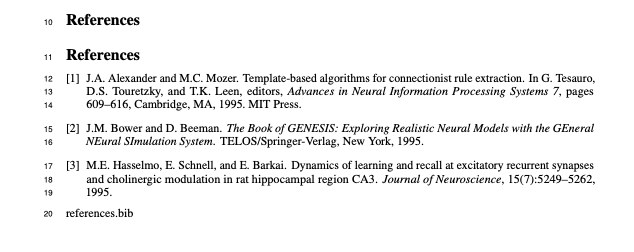

Probably it's still defining References as its own section from the "## References" in the doc, and then doing it again via the special references flag in the neurips template. We look at the LaTeX, we see this: 
```latex
\section*{References}
\small

\bibliographystyle{unsrt}
 


references.bib
```
...the problem is actually something unanticipated.   Namely that calling `\bibliography{references}` actually adds its own `\section*{References}` somehow internally.   Here's what we actually want in the end: 

```latex
%\section*{References}
\small

\bibliographystyle{unsrt}
\bibliography{references}


%references.bib
```
Those two lines that I added comments to, we can either make them comments or just not print them.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Looking at the issue, the `\bibliography{references}` command automatically adds its own section heading, so we don't need the explicit `\section*{References}`. Let me fix the `export_ipynb_to_tex` function:





<details class='tool-usage-details' markdown='1'>
<summary><code>python(code=&quot;import inspect\nsrc = inspect.getsource(e…&quot;)→&quot;def export_ipynb_to_tex(ipynb_path: str,…&quot;</code></summary>

```json
{
  "id": "call_72e55381608a4622975d50f7",
  "server": false,
  "call": {
    "function": "python",
    "arguments": {
      "code": "import inspect\nsrc = inspect.getsource(export_ipynb_to_tex)\nprint(src)"
    }
  },
  "result": "def export_ipynb_to_tex(ipynb_path: str, output_path: str = None):\n    \"Export a Solveit dialog (.ipynb) to a compilable LaTeX file.\"\n    \n    ipynb_path = os.path.expanduser(ipynb_path)\n    output_path = os.path.expanduser(output_path) if output_path else Path(ipynb_path).with_suffix('.tex')\n\n    nb = json.loads(Path(ipynb_path).read_text())\n    preamble_lines = []\n    body_lines = []\n    past_abstract = False\n\n    for cell in nb['cells']:\n        content = ''.join(cell['source'])\n\n        if cell['cell_type'] != 'raw' and '#| export' not in content:\n            continue\n\n        if cell['cell_type'] == 'raw' and '#| export' not in content:\n            continue\n\n        filtered = '\\n'.join(l for l in content.split('\\n') if not l.startswith('#| '))\n\n        if cell['cell_type'] == 'raw' and not past_abstract:\n            preamble_lines.append(filtered)\n            continue\n\n        lines = filtered.split('\\n')\n        i = 0\n        while i < len(lines):\n            line = lines[i]\n\n            if line.startswith('# ') and not line.startswith('## '):\n                preamble_lines.append(f'\\\\title{{{line[2:].strip()}}}\\n')\n            elif line.startswith('\\\\author{'):\n                preamble_lines.append(line)\n                while i < len(lines) and not lines[i].strip().endswith('}'):\n                    i += 1\n                    if i < len(lines):\n                        preamble_lines.append(lines[i])\n                preamble_lines.append('\\\\begin{document}\\n\\\\maketitle\\n')\n            elif line == '## Abstract':\n                preamble_lines.append('\\\\begin{abstract}\\n')\n                i += 1\n                while i < len(lines) and not lines[i].startswith('## '):\n                    preamble_lines.append(lines[i])\n                    i += 1\n                preamble_lines.append('\\\\end{abstract}\\n')\n                past_abstract = True\n                continue\n            elif line == '## References':\n                body_lines.append('\\\\section*{References}\\n\\\\small\\n')\n                bib_match = re.search(r'(\\w+)\\.bib', content)\n                if bib_match:\n                    body_lines.append(f'\\\\bibliographystyle{{unsrt}}\\n\\\\bibliography{{{bib_match.group(1)}}}\\n')\n                i += 1\n                continue\n            elif line.startswith('### '):\n                body_lines.append(f'\\\\subsection{{{line[4:].strip()}}}\\n')\n            elif line.startswith('## '):\n                body_lines.append(f'\\\\section{{{line[3:].strip()}}}\\n')\n            else:\n                body_lines.append(line)\n\n            i += 1\n\n    final = '\\\\documentclass{article}\\n\\n'\n    final += '\\n'.join(preamble_lines) + '\\n\\n'\n    final += '\\n'.join(body_lines) + '\\n\\n'\n    final += '\\\\end{document}\\n'\n    Path(output_path).write_text(final)\n    print(f'Created {output_path}')"
}
```

</details>







I can see the issue. The `## References` handler is explicitly adding `\section*{References}`, but `\bibliography{references}` adds its own heading automatically. Let me fix this:





<details class='tool-usage-details' markdown='1'>
<summary><code>python(code=&quot;def export_ipynb_to_tex(ipynb_path: str,…&quot;)→&quot;PermissionError: def/class not allowed: …&quot;</code></summary>

```json
{
  "id": "call_e1f8b1ee2e474c04a7122d3f",
  "server": false,
  "call": {
    "function": "python",
    "arguments": {
      "code": "def export_ipynb_to_tex(ipynb_path: str, output_path: str = None):\n    \"Export a Solveit dialog (.ipynb) to a compilable LaTeX file.\"\n    \n    ipynb_path = os.path.expanduser(ipynb_path)\n    output_path = os.path.expanduser(output_path) if output_path else Path(ipynb_path).with_suffix('.tex')\n\n    nb = json.loads(Path(ipynb_path).read_text())\n    preamble_lines = []\n    body_lines = []\n    past_abstract = False\n\n    for cell in nb['cells']:\n        content = ''.join(cell['source'])\n\n        if cell['cell_type'] != 'raw' and '#| export' not in content:\n            continue\n\n        if cell['cell_type'] == 'raw' and '#| export' not in content:\n            continue\n\n        filtered = '\\n'.join(l for l in content.split('\\n') if not l.startswith('#| '))\n\n        if cell['cell_type'] == 'raw' and not past_abstract:\n            preamble_lines.append(filtered)\n            continue\n\n        lines = filtered.split('\\n')\n        i = 0\n        while i < len(lines):\n            line = lines[i]\n\n            if line.startswith('# ') and not line.startswith('## '):\n                preamble_lines.append(f'\\\\title{{{line[2:].strip()}}}\\n')\n            elif line.startswith('\\\\author{'):\n                preamble_lines.append(line)\n                while i < len(lines) and not lines[i].strip().endswith('}'):\n                    i += 1\n                    if i < len(lines):\n                        preamble_lines.append(lines[i])\n                preamble_lines.append('\\\\begin{document}\\n\\\\maketitle\\n')\n            elif line == '## Abstract':\n                preamble_lines.append('\\\\begin{abstract}\\n')\n                i += 1\n                while i < len(lines) and not lines[i].startswith('## '):\n                    preamble_lines.append(lines[i])\n                    i += 1\n                preamble_lines.append('\\\\end{abstract}\\n')\n                past_abstract = True\n                continue\n            elif line == '## References':\n                body_lines.append('\\\\small\\n')\n                bib_match = re.search(r'(\\w+)\\.bib', content)\n                if bib_match:\n                    body_lines.append(f'\\\\bibliographystyle{{unsrt}}\\n\\\\bibliography{{{bib_match.group(1)}}}\\n')\n                i += 1\n                continue\n            elif line.startswith('### '):\n                body_lines.append(f'\\\\subsection{{{line[4:].strip()}}}\\n')\n            elif line.startswith('## '):\n                body_lines.append(f'\\\\section{{{line[3:].strip()}}}\\n')\n            else:\n                body_lines.append(line)\n\n            i += 1\n\n    final = '\\\\documentclass{article}\\n\\n'\n    final += '\\n'.join(preamble_lines) + '\\n\\n'\n    final += '\\n'.join(body_lines) + '\\n\\n'\n    final += '\\\\end{document}\\n'\n    Path(output_path).write_text(final)\n    print(f'Created {output_path}')"
    }
  },
  "result": "PermissionError: def/class not allowed: export_ipynb_to_tex. Code message has been added to dialog. Ask user to run it."
}
```

</details>







I found the issue and wrote the fix. The `export_ipynb_to_tex` function was explicitly adding `\section*{References}` when it encountered `## References`, but `\bibliography{references}` automatically generates its own section heading, causing the duplicate.

The fix is simple: remove the `\section*{References}` line from the References handler. I changed:
```python
body_lines.append('\\section*{References}\n\\small\n')
```
to:
```python
body_lines.append('\\small\n')
```

The code message was added to your dialog but couldn't run automatically due to the `def` restriction. Could you run that message to apply the fix? Then we can re-export and recompile to verify the duplicate heading is gone.